<a href="https://colab.research.google.com/github/ashaw23871/SmartCart-clustering/blob/main/SmartCart_clustering_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/drive/MyDrive/smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
# feature engineering - combining features, making them more meaningful amd removing unnecessay features, preventing cure of dimensionanlity
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age'],
      dtype='object')

In [9]:
# expense
df["Total_expense"] =  df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [10]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

In [11]:
df["Education"].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [12]:
df["Education"] = df["Education"].map({
    "Graduation":"Graduate",
    "PhD":"Post-Graduate",
    "Master":"Post-Graduate",
    "2n Cycle":"Under-Graduate",
    "Basic":"Under-Graduate"
})

In [13]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [14]:
df["Living_With"] = df["Marital_Status"].map({
    "Married":"Partner",
    "Together":"Partner",
     "Single":"Alone",
     "Divorced":"Alone",
     "Widow":"Alone",
     "Alone":"Alone",
     "Absurd":"Alone",
     "YOLO":"Alone"
})

In [15]:
df["Living_With"].value_counts()

,count
Living_With,
Partner,1444
Alone,796


In [16]:
df["Children"] = df["Kidhome"] + df["Teenhome"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_expense,Customer_Tenure_Days,Living_With,Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,1617,663,Alone,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,27,113,Alone,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,776,312,Partner,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,53,139,Partner,1
4,5324,1981,Post-Graduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,422,161,Partner,1


In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Total_expense', 'Customer_Tenure_Days',
       'Living_With', 'Children'],
      dtype='object')

In [19]:
cols = ['ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
df_cleaned = df.drop(columns=cols)

In [20]:
df.shape

(2240, 27)

In [21]:
df_cleaned.shape

(2240, 15)

In [22]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Total_expense',
       'Customer_Tenure_Days', 'Living_With', 'Children'],
      dtype='object')

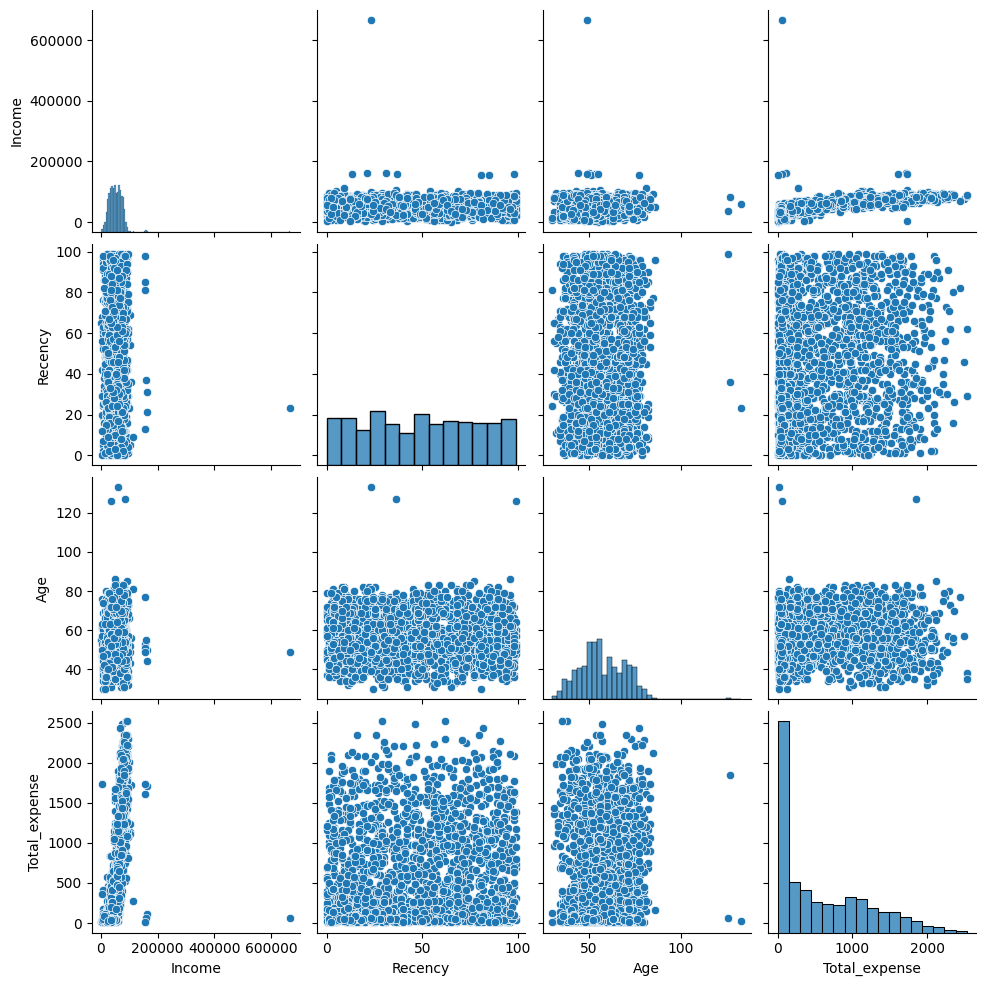

In [23]:
# outlier detection and removal
import seaborn as sns
cols = ['Income', 'Recency', 'Age', 'Total_expense']
sns.pairplot(df_cleaned[cols])

In [24]:
df_cleaned = df_cleaned[df_cleaned["Income"] < 600_000]

df_cleaned = df_cleaned[df_cleaned["Age"] < 90]

In [25]:
len(df)

2240

In [26]:
len(df_cleaned)

2236

**Heat Map**

In [27]:
import matplotlib.pyplot as plt

In [28]:
#correlation matrix
corrM = df_cleaned.corr(numeric_only=True)

<Axes: >

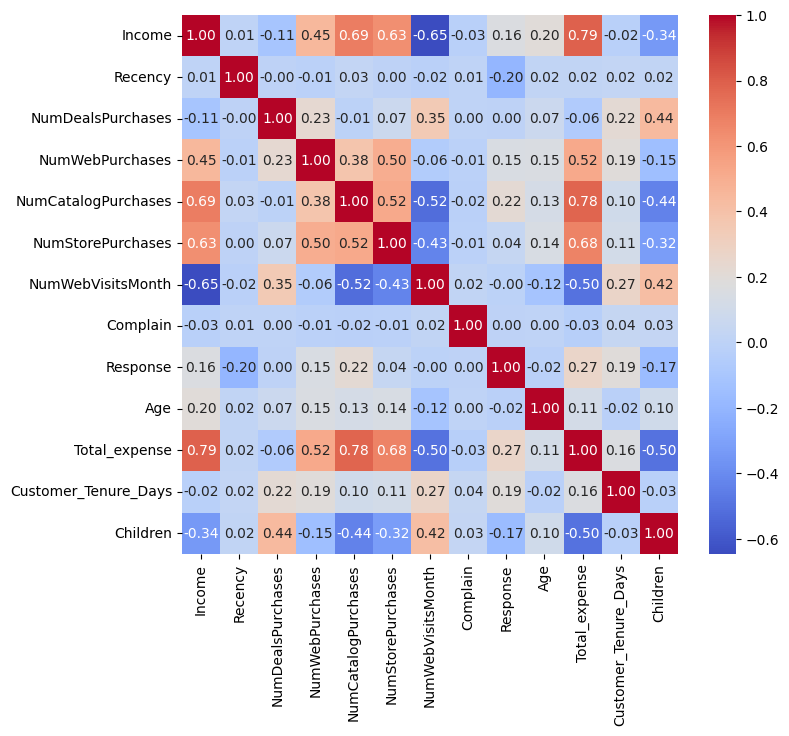

In [29]:
plt.figure(figsize = (8,7))
sns.heatmap(
    corrM,
    annot=True,
    cmap ='coolwarm',
    fmt='.2f')

# Encoding

In [30]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_expense,Customer_Tenure_Days,Living_With,Children
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,1617,663,Alone,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,27,113,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,776,312,Partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,53,139,Partner,1
4,Post-Graduate,58293.0,94,5,5,3,6,5,0,0,45,422,161,Partner,1


In [31]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False) #dropfirst=True not required in clustering. SML-multicollinearilty
cols = ['Education', 'Living_With']
encoded = ohe.fit_transform(df_cleaned[cols])

In [33]:
ohe.get_feature_names_out()

array(['Education_Graduate', 'Education_Post-Graduate',
       'Education_Under-Graduate', 'Living_With_Alone',
       'Living_With_Partner'], dtype=object)

In [34]:
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(),index = df_cleaned.index)

In [35]:
encoded_df.head()

,Education_Graduate,Education_Post-Graduate,Education_Under-Graduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [36]:
X = pd.concat([df_cleaned.drop(columns=cols) , encoded_df],axis=1)

In [37]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_expense,Customer_Tenure_Days,Children,Education_Graduate,Education_Post-Graduate,Education_Under-Graduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,1617,663,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,27,113,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,776,312,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,53,139,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,422,161,1,0.0,1.0,0.0,0.0,1.0


# Scaling


In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# Visualise

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [41]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

In [42]:
# 23+11+10 = only 44% info captured

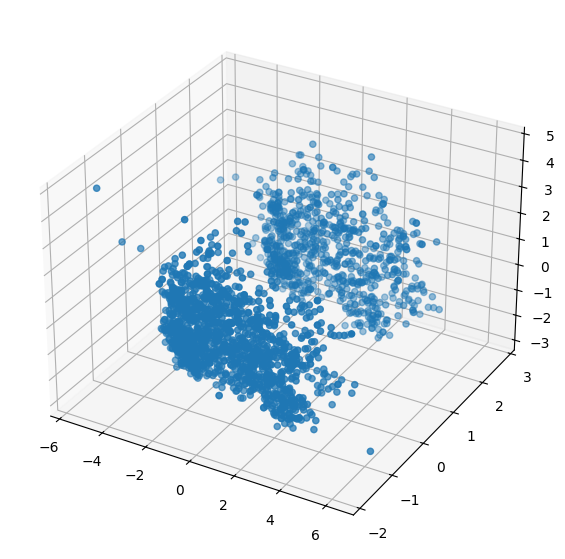

In [43]:
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

# Analyse K value


**1. Elbow Method**

In [44]:
pip install kneed

In [45]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit_predict(X_pca)
  wcss.append(kmeans.inertia_)


In [46]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_K = knee.elbow

In [47]:
print(optimal_K)

4


<Axes: >

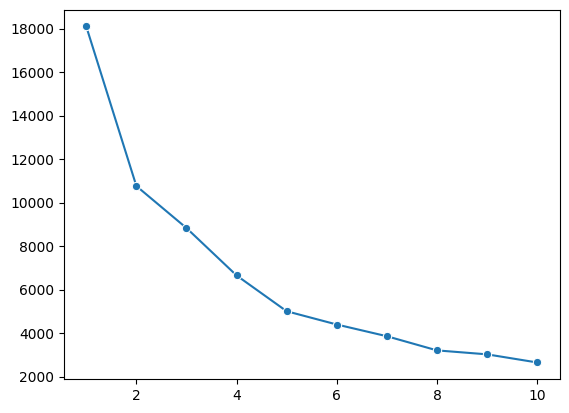

In [48]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

**2.Silhouette score**

In [49]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
  kmeans = KMeans(n_clusters=k,random_state=42)
  labels = kmeans.fit_predict(X_pca)
  score = silhouette_score(X_pca,labels)
  scores.append(score)


<Axes: >

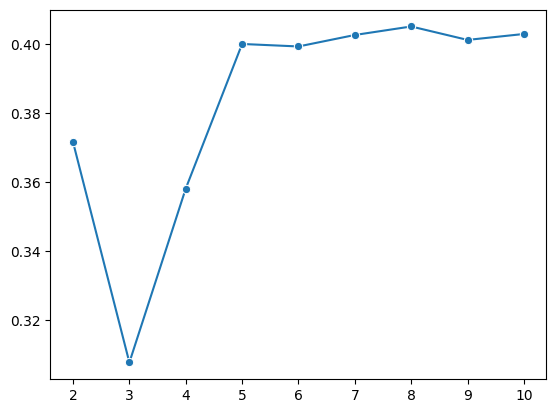

In [50]:
sns.lineplot(x=range(2,11),y=scores,marker="o")

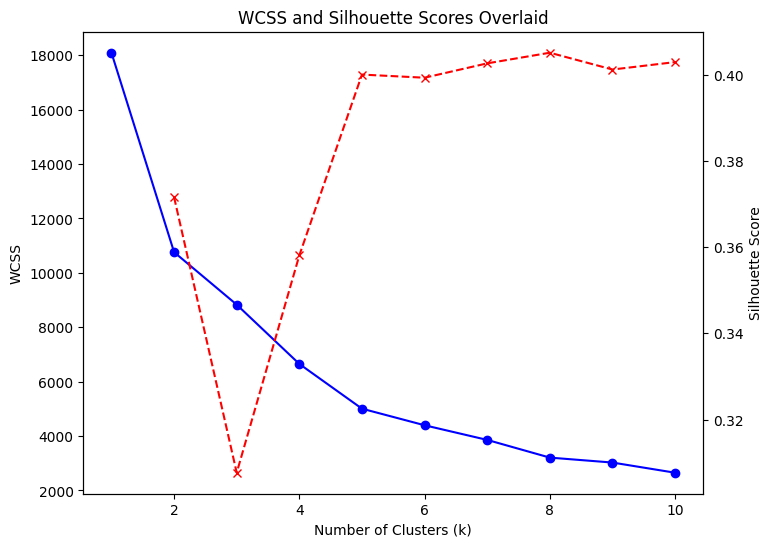

In [51]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot WCSS on the primary Y-axis (Left)
ax1.plot(range(1, 11), wcss, 'o-b', label='WCSS')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS')


# Create a twin axis for Silhouette Scores (Right)
ax2 = ax1.twinx()
ax2.plot(range(2, 11), scores, "x--r", label='Silhouette Score')
ax2.set_ylabel('Silhouette Score')


plt.title('WCSS and Silhouette Scores Overlaid')
plt.show()

# KMeans

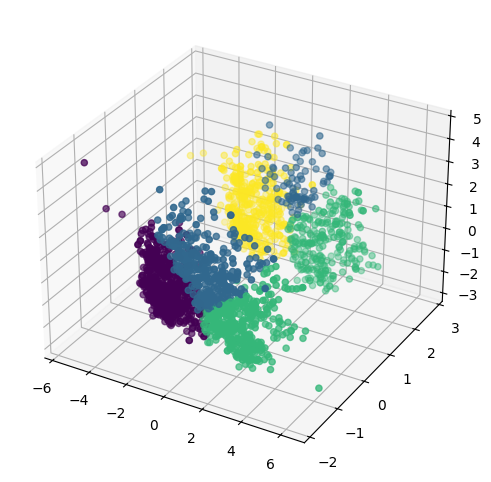

In [52]:
kmeans = KMeans(n_clusters=4,random_state=42)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

# Agglomerative clustering

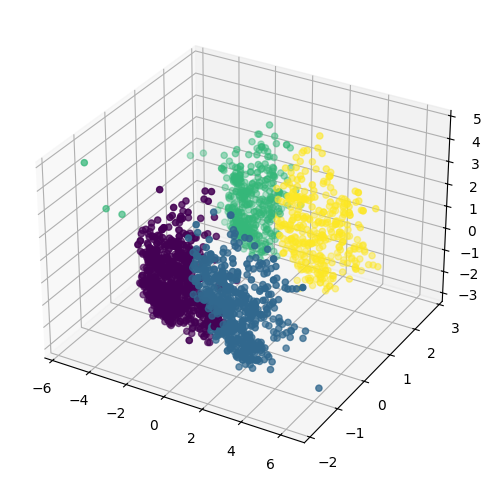

In [54]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

<Axes: xlabel='Clusters', ylabel='count'>

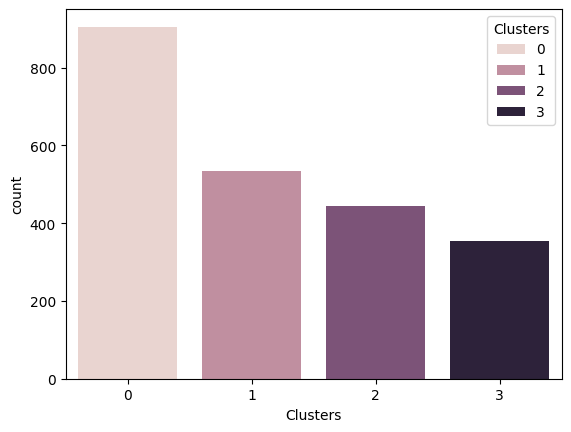

In [67]:
# Characterization
X["Clusters"] = labels_agg

sns.countplot(data = X,x= "Clusters",hue = "Clusters")

<Axes: xlabel='Income', ylabel='Total_expense'>

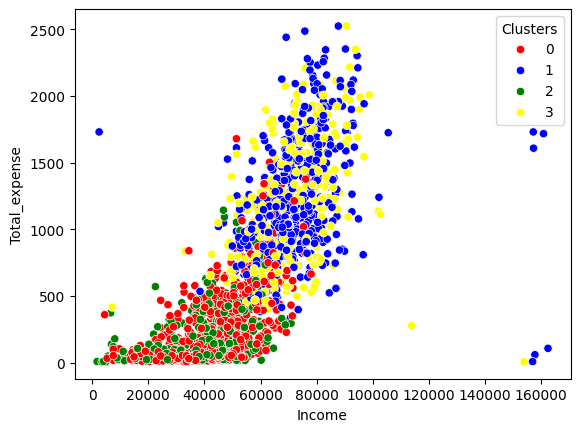

In [68]:
pal = ["red","blue","green","yellow"]
sns.scatterplot(data = X,x = "Income",y = "Total_expense",hue="Clusters",palette=pal)

In [ ]:
# cluster 0 and 2 - low income and low expense - price sensitive customer
# cluster 1 and 3 - high income and high expense - premium customer

In [75]:
X.groupby("Clusters").mean()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_expense,Customer_Tenure_Days,Children,Education_Graduate,Education_Post-Graduate,Education_Under-Graduate,Living_With_Alone,Living_With_Partner
Clusters,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,221.955801,342.939227,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,1236.588015,369.720974,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,165.702703,338.781532,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,1190.385269,376.280453,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


'''
Cluster 0: "Budget-Conscious Families"
Summary: These customers have moderate income but low overall spending, indicating high price sensitivity. They are typically older, have more children, and live with a partner. They frequently browse online but prefer making purchases in-store, often driven by deals.
Advertising Ideas:
- Value & Deals: Promote discounts, bulk offers, and loyalty programs.
- Family-Oriented Products: Focus on necessities and products for households with children.
- In-Store Promotions: Highlight in-store sales, special events, and clear signage for discounts.
- Digital-to-Physical Path: Use online ads to drive traffic to physical stores for deals.

Cluster 1: "Affluent & Engaged Couples"
Summary: This cluster represents high-income, high-spending customers, usually living with partners and having fewer children. They are highly engaged across all shopping channels (web, catalog, and store), prioritize convenience and quality over deals, and are quite responsive to marketing efforts.
Advertising Ideas:
- Premium & Exclusive: Showcase high-quality, luxury products, and exclusive collections.
- Convenience & Personalization: Emphasize personalized recommendations, fast delivery, and seamless multi-channel shopping experiences.
- Lifestyle Marketing: Ads should appeal to their sophisticated lifestyle, perhaps featuring travel, fine dining, or unique experiences.
- Rewards & Loyalty: Offer tiered loyalty programs with exclusive perks and early access.

Cluster 2: "Deal-Seeking Solo Parents"
Summary: These customers have the lowest income and lowest spending among all clusters. They typically live alone but have the highest number of children. They are extremely price-sensitive, visit websites very frequently to find deals, but make very few catalog or web purchases, often preferring in-store options for necessities.
Advertising Ideas:
- Extreme Value & Essentials: Focus heavily on deep discounts, clearance sales, and essential goods at rock-bottom prices.
- Flash Sales & Coupons: Promote limited-time offers, digital coupons, and rebate programs.
- Digital Engagement (Value-driven): Target with online ads highlighting savings, budget-friendly meal solutions, and school supplies deals.
- Emphasize Practicality: Messaging should focus on how products solve daily challenges for single-parent households affordably.

Cluster 3: "High-Value Independent Individuals"
Summary: This cluster consists of high-income, high-spending individuals who live alone and have very few or no children. They are highly responsive to marketing campaigns and purchase frequently across all channels, valuing quality and unique offerings. They are less interested in deals and more in a curated experience.
Advertising Ideas:
- Curated & Unique: Offer personalized shopping experiences, unique products, and bespoke services.
- Self-Indulgence & Hobbies: Ads should appeal to their independence and personal interests (e.g., high-end gadgets, travel, specialized hobbies, wellness).
- VIP Access & Experiences: Provide early access to new products, exclusive events, and premium services.
- Direct & Personalized Communication: Use email and direct mail with highly tailored content that speaks to their individual desires.
'''